In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np
from tabulate import tabulate

# Message Distribution Demo

In [4]:
# load data
with open('data/2-hosts-200-messages-distribution.json', 'r') as file:
    data = json.load(file)

print(data)

{'HELLO': 2, 'FEATURES_REQUEST': 1, 'FEATURES_REPLY': 1, 'STATS_REQUEST': 47, 'STATS_REPLY': 47, 'BARRIER_REQUEST': 9, 'GET_CONFIG_REQUEST': 1, 'BARRIER_REPLY': 9, 'GET_CONFIG_REPLY': 1, 'ROLE_REQUEST': 2, 'ROLE_REPLY': 2, 'PACKET_OUT': 65, 'FLOW_MOD': 8, 'PACKET_IN': 6}


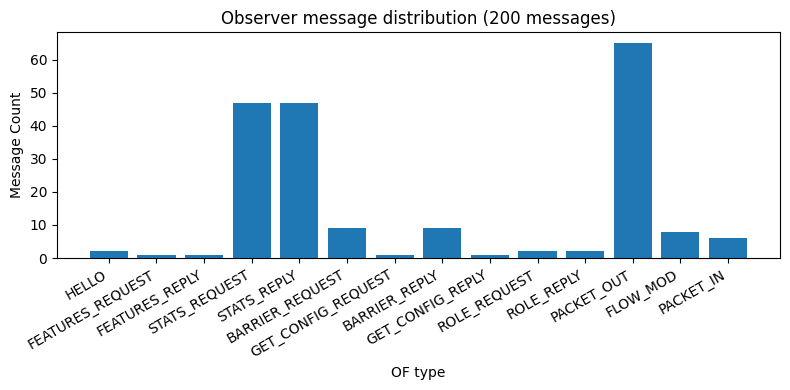

In [6]:
labels = list(data.keys())
values = list(data.values())

plt.figure(figsize=(8, 4))
plt.bar(labels, values)
plt.xlabel("OF type")
plt.ylabel("Message Count")
plt.title("Observer message distribution (200 messages)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Delay Graph

In [3]:
data_sources = {
    '500': 'data/0.5k-flows.txt',
    '1000': 'data/1k-flows.txt',
    '2000': 'data/2k-flows.txt',
    '3000': 'data/3k-flows.txt',
    '5000': 'data/5k-flows.txt'
}

data = {
    '500': [],
    '1000': [],
    '2000': [],
    '3000': [],
    '5000': []
}

for k, v in data_sources.items():
    with open(v, 'r') as f:
        lines = [float(l.replace('\n', '')) for l in f.readlines()[:100]]

        data[k] = lines

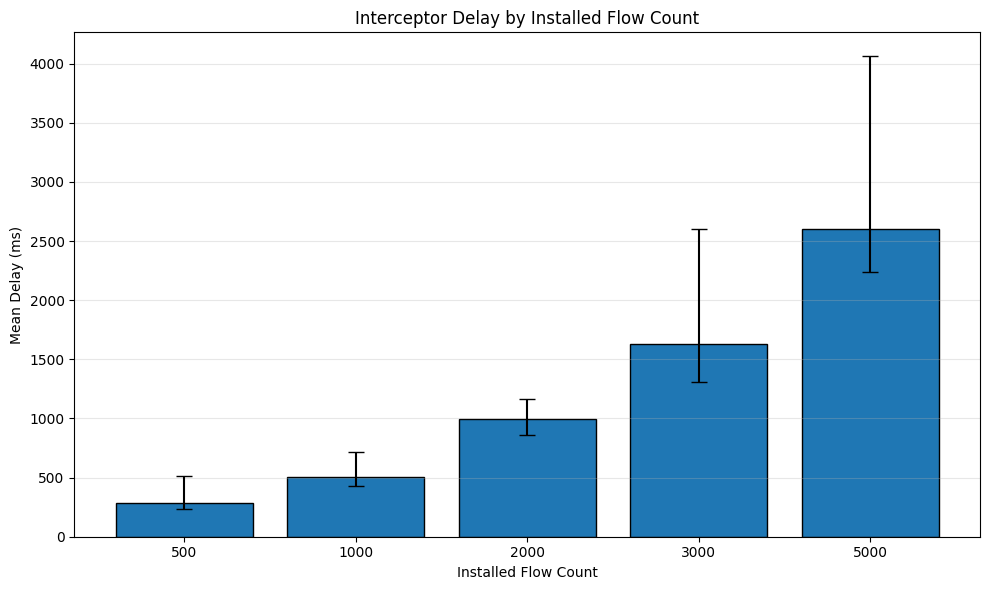

In [4]:
flow_counts = sorted(data.keys(), key=lambda x: int(x))
delay_values = [data[count] for count in flow_counts]

means = [np.mean(values) for values in delay_values]
mins = [np.min(values) for values in delay_values]
maxs = [np.max(values) for values in delay_values]

lower_errors = [mean - min_val for mean, min_val in zip(means, mins)]
upper_errors = [max_val - mean for mean, max_val in zip(means, maxs)]

plt.figure(figsize=(10, 6))
plt.bar(
    flow_counts,
    means,
    yerr=[lower_errors, upper_errors],
    capsize=6,
    edgecolor="black",
)

plt.title("Interceptor Delay by Installed Flow Count")
plt.xlabel("Installed Flow Count")
plt.ylabel("Mean Delay (ms)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
rows = []

for flow_count in sorted(data.keys(), key=lambda x: int(x)):
    values = np.array(data[flow_count])

    rows.append([
        flow_count,
        np.mean(values),
        np.std(values),
        np.min(values),
        np.max(values),
    ])

print(tabulate(
    rows,
    headers=["# of Installed Flows", "Mean (ms)", "Std (ms)", "Min (ms)", "Max (ms)"],
    floatfmt=".3f",
    tablefmt="github",
))

|   # of Installed Flows |   Mean (ms) |   Std (ms) |   Min (ms) |   Max (ms) |
|------------------------|-------------|------------|------------|------------|
|                    500 |     282.562 |     35.677 |    230.550 |    514.690 |
|                   1000 |     501.255 |     45.808 |    426.210 |    719.290 |
|                   2000 |     994.703 |     65.741 |    861.950 |   1160.870 |
|                   3000 |    1632.190 |    231.171 |   1304.630 |   2605.480 |
|                   5000 |    2602.570 |    265.597 |   2241.450 |   4061.660 |
